# MNIST Dataset ML Project
Dataset from [Here]()

## Setup

### Import Packages

In [1]:
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import torch.nn.functional as F # Will use later
from tqdm.auto import tqdm
import torch.nn as nn # Will use later
import numpy as np
import torchvision
import torch

### MNIST Dataset Processing Pipeline

#### Import Data

In [2]:
# May have to do a lot of different stuff, load from dataset, normalize (lookup what that means), load both the train and the test sets, etc.

# Resizing the images to match the input of the CNN class defined below
Transform = v2.Compose([torchvision.transforms.v2.Resize(size=(32,32),interpolation='bilinear'),
                        torchvision.transforms.v2.ToImage(), 
                        torchvision.transforms.v2.ToDtype(torch.float32,scale=True)])

training_data = torchvision.datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=Transform #Look up what this is doing to the data in a little
)

test_data = torchvision.datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=Transform
    )

In [3]:
# Works only if transform is commented out, as images have been transformed from PIL -> PyTorch tensors
#for i in range(10):
#    plt.imshow(training_data[i][0], cmap='grey')
#    plt.title(f"Example of class '{training_data[i][1]}'")
#    plt.show()

In [4]:
#labels_map = training_data.classes

#figure = plt.figure(figsize=(8, 8))
#cols, rows = 3, 3
#for i in range(1, cols * rows + 1):
#    sample_idx = torch.randint(len(training_data), size=(1,)).item()
#    img, label = training_data[sample_idx]
#    figure.add_subplot(rows, cols, i)
#    plt.title(labels_map[label])
#    plt.axis("off")
#    plt.imshow(img, cmap="gray")
#plt.show()

#### Etc... (Validation, Padding if necessary, Showing examples, Printing out names of all available classes)

In [5]:
training_data.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [6]:
len(training_data)

60000

In [7]:
CLASSES = training_data.class_to_idx

print(list(CLASSES))

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [8]:
print(training_data[0][1])

5


In [9]:
help(training_data)

Help on MNIST in module torchvision.datasets.mnist object:

class MNIST(torchvision.datasets.vision.VisionDataset)
 |  MNIST(
 |      root: Union[str, Path],
 |      train: bool = True,
 |      transform: Optional[Callable] = None,
 |      target_transform: Optional[Callable] = None,
 |      download: bool = False
 |  ) -> None
 |
 |  `MNIST <http://yann.lecun.com/exdb/mnist/>`_ Dataset.
 |
 |  Args:
 |      root (str or ``pathlib.Path``): Root directory of dataset where ``MNIST/raw/train-images-idx3-ubyte``
 |          and  ``MNIST/raw/t10k-images-idx3-ubyte`` exist.
 |      train (bool, optional): If True, creates dataset from ``train-images-idx3-ubyte``,
 |          otherwise from ``t10k-images-idx3-ubyte``.
 |      transform (callable, optional): A function/transform that  takes in a PIL image
 |          and returns a transformed version. E.g, ``transforms.RandomCrop``
 |      target_transform (callable, optional): A function/transform that takes in the
 |          target and tran

## Modelling Data

### Setting Up Layer Architecture (Defining the NN)
Based on the following architecture:

![image](https://docs.pytorch.org/tutorials/_images/mnist.png)

In [10]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__() # Import methods from inherited class

        ## Will take in our 32x32 image and output 6 feature maps of 32-5+1 = 28; 
        #   -5 is the kernel size, and +1 is for the first 5x5 convolution / starting map, 
        #   This along both axes yields 6 resulting (images) feature maps of 28x28
        self.conv_1 = torch.nn.Conv2d(in_channels=1, # Base single image is taken in,
                                      out_channels=6, # 6 Separate kernels used yield 6 separate
                                                      # output activation maps, we train the kernels 
                                                      # that yield those activation maps
                                      kernel_size=5) # 5x5 Convolution square that defines the size of 
                                                     # a single kernel.
        ## Taking in the 6 feature maps from the 6 different kernels at a pre-max-pooled 28x28 / 2 = 14x14;
        #   Using the same 5x5 size of kernel for 16 different feature map outputs: 14-5+1 = 10;
        #   This yields 16 output activation maps of 10x10 pixels
        self.conv_2 = torch.nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5) 

        self.linear_1 = torch.nn.Linear(in_features = 16 * 5*5, # Take in the number of pixels total from 
                                                                # the last (second) convolution layer's pooling.
                                        out_features = 120) # Output as 120 neurons of a 1D NN.
        self.linear_2 = torch.nn.Linear(in_features=120,out_features=84) # ''
        self.linear_3 = torch.nn.Linear(in_features=84,out_features=10) # ''

    def forward(self,input):
        # First layer:  Convolution 1 'c1' takes the input and uses the ReLU activation 
        #               function on the raw value of each 5x5 kernel's output
        c1 = torch.nn.functional.relu(self.conv_1(input)) 
        # Second layer: Subsampling (Max Pooling) 1 's2' uses a 2x2 kernel and instead of 
        #               striding like in a convolution layer, the max value within the 
        #               2x2 block is taken and the stride is 2 over (there is no overlap 
        #               from pool output pixel to pool output pixel w.r.t. the input block)
        #               Thus the lengths of the c1 out map are halved on both sides.
        s2 = torch.nn.functional.max_pool2d(c1, (2,2))
        # Third layer:  Convolution 2 'c3' takes the input from the max pool layer and uses
        #               the ReLU activation function on the raw value of each 5x5 kernel output
        c3 = torch.nn.functional.relu(self.conv_2(s2))
        # Fourth layer: Subsampling (Max Pooling) 2 's4' takes the 10x10 output of 'c3' and
        #               uses a 2x2 max value pooling function to halve the feature map to
        #               final feature map 'image' dimensions of 5x5
        s4 = torch.nn.functional.max_pool2d(c3,(2,2))
        # Flattening with torch.flatten() takes the 16 output pooled images of 5x5 each 
        # (400 pixels total) and returns 1 1D view of each image condensed into a single 1D vector
        # for the entire set of images passed (N input images -> 1 output image)
        # i.e. torch.flatten([[1,2,3],[4,5,6],[7,8,9]]) => [1,2,3,4,5,6,7,8,9]
        s4 = torch.flatten(input=s4,start_dim=1) # We get an output vector of length 400
        # Fifth layer:  Fully interconnected 1D linear NN layer 1 'f5' takes in the flattened s4 
        #               vector of length 400 and, for each of the 120 individual neuron, takes the sum of 
        #               all 400 input vector values, multiplies them by their neuron-specific weight (plus 
        #               the neuron-specific bias) and that sum is what is passed through the ReLU to get 
        #               the throughput of that neuron in the output vector of length 120
        f5 = torch.nn.functional.relu(self.linear_1(s4))
        # Sixth layer:  Now it's just a regular old fully connected neural network, compressing down the
        #               signal of a 120 neuron input to 84 neurons in this layer. 
        f6 = torch.nn.functional.relu(self.linear_2(f5))
        # Seventh layer:Last layer, just compresses the ouput of the 84 dimensional vector from 'f6' to
        #               a 10 dimensional layer, no activation function to preserve any negative signals,
        #               the network's loss is calculated directly on the output of the 10 dimensional layer. 
        output = self.linear_3(f6)
        return output

cnn = CNN()
#print(cnn)

In [11]:
input = torch.randn(1,1,32,32)
out=cnn(input)
print(out)

tensor([[ 0.1119,  0.0123, -0.0527,  0.0683,  0.0513,  0.1091,  0.0869,  0.1382,
         -0.0152, -0.0275]], grad_fn=<AddmmBackward0>)


### Loss function

In [12]:
criterion = torch.nn.CrossEntropyLoss() # Defining the loss metric we will be using
optimizer = torch.optim.SGD(cnn.parameters(),lr=0.001,momentum=0.9) # Initializing our optimizer

#### 

#### Loading Data

In [13]:
training_set = torch.utils.data.DataLoader(training_data, batch_size=64,shuffle=True,num_workers=4)

test_set = torch.utils.data.DataLoader(test_data, batch_size=64,shuffle=True,num_workers=4)

### Training Loop

In [14]:
N_EPOCHS = 3
len_train = len(training_set)
epoch_bar = tqdm(range(N_EPOCHS),desc='Training CNN Model',unit='epoch')

# Using TQDM to visualize training progress
LOSS_VALUES = []
for epoch in epoch_bar:
    running_loss = 0.0
    batch_bar = tqdm(training_set,desc=f"Epoch: {epoch+1}",leave=False)
    
    # Enumerating through training_set, starting at a counter of 0,
    # i is current batch number, data is the list of [input X, targets y]
    for i, data in enumerate(batch_bar,0): 
        inputs, labels = data

        optimizer.zero_grad() # Zero the parameter gradients to clear any prev. values
        
        ## Process input through the network
        outputs = cnn(inputs)

        ## Compute the loss
        loss = criterion(outputs,labels)
        LOSS_VALUES.append(loss) # Store for plotting 

        ## Propagate gadients back into the network's parameters
        loss.backward() # Assign loss blame to individual params
        
        ## Update weights of the network
        optimizer.step() # Adjust params wrt individual losses 

        running_loss += loss.item()

        batch_bar.set_postfix({"Batch Loss":f"{loss.item():.4f}"})
        
        average_epoch_loss = running_loss/len_train

Training CNN Model:   0%|          | 0/3 [00:00<?, ?epoch/s]

Epoch: 1:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch: 2:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch: 3:   0%|          | 0/938 [00:00<?, ?it/s]

In [26]:
#print(LOSS_VALUES[:5]) # Whoops, accidentally recorded tensors instead of the raw numbers

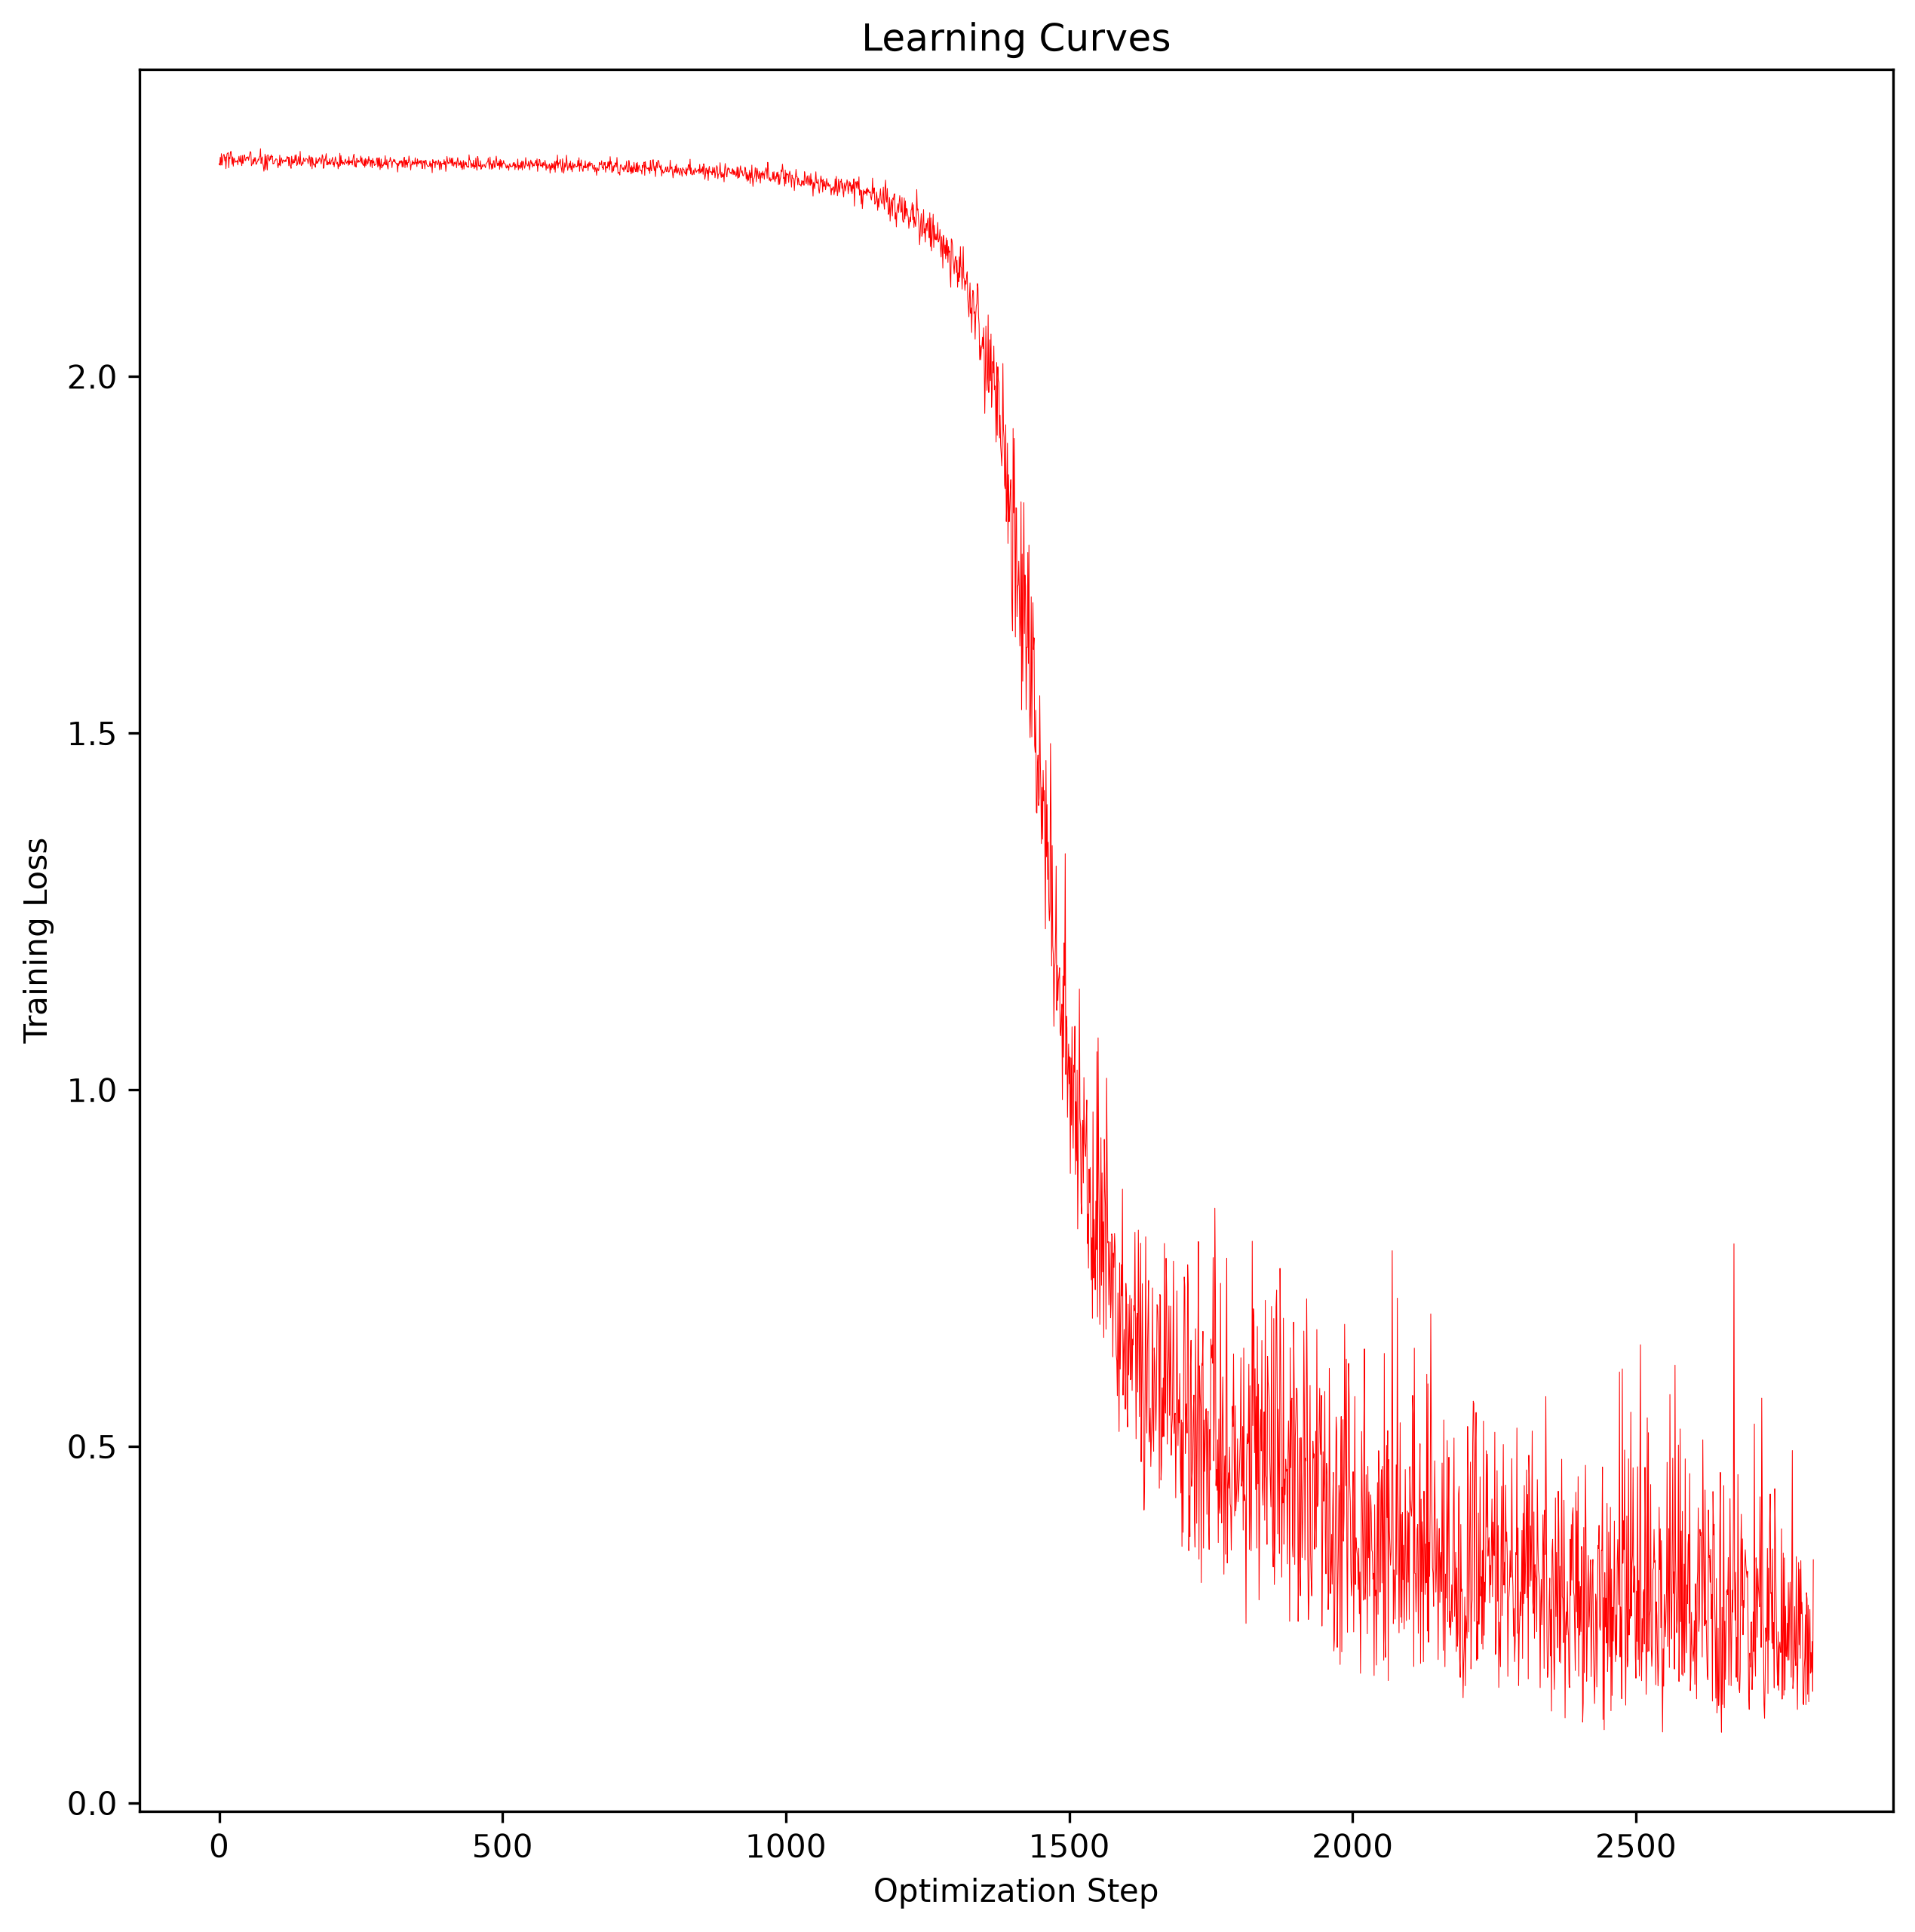

In [40]:
NUMPY_LOSSES = [x.detach().numpy() for x in LOSS_VALUES] # Convert those stored tensors into floats
plt.subplots(figsize=(10,10),dpi=300)
plt.plot(NUMPY_LOSSES,linewidth=0.25,c='r')
plt.title("Learning Curves")
plt.xlabel('Optimization Step')
plt.ylabel('Training Loss')
plt.show()

## Results on Test Set

## Another Paper
From [Here]()
Goals:
- Reproduce architecture
- Report on how that affects results obtained for MNIST Dataset
- Compare both architectures using CIFAR10 Dataset found [Here]()
- How do the two methods compare now?

### Reproducing Paper's Network Architecture

### MNIST

#### Training Loop

#### Results

#### Comparison

### CIFAR10

#### Trianing Loop

#### Results

#### Comparison